Import Libraries

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

from imblearn.over_sampling import SMOTE
import shap

 Load Dataset

In [50]:
data = pd.read_csv("default_of_credit_card_clients.csv")

data = data.drop("ID",axis=1)

data.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


EDA

In [51]:
#Dataset Shape
print(data.shape)

(30000, 24)


In [52]:
#Missing values
data.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [53]:
#Class imbalance
data["default payment next month"].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

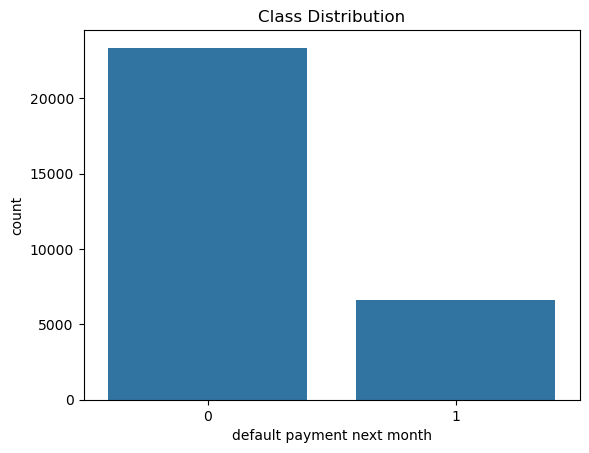

In [54]:
#Plot imbalance
sns.countplot(x="default payment next month",data=data)
plt.title("Class Distribution")
plt.show()

Split Features and Target

In [55]:
X = data.drop("default payment next month",axis=1)
y = data["default payment next month"]
X.shape,y.shape

((30000, 23), (30000,))

Train Test Split

In [56]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((24000, 23), (6000, 23), (24000,), (6000,))

 Handle Imbalance (SMOTE)

In [57]:
print("Before SMOTE")
print(y_train.value_counts())

sm = SMOTE(random_state=42)
X_train,y_train = sm.fit_resample(X_train,y_train)

print("After SMOTE")
print(pd.Series(y_train).value_counts())

Before SMOTE
default payment next month
0    18691
1     5309
Name: count, dtype: int64
After SMOTE
default payment next month
0    18691
1    18691
Name: count, dtype: int64


 Scaling

In [58]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train
X_test


array([[-0.82325254, -1.01319496,  0.32425692, ..., -0.13401319,
        -0.17305041, -0.1014378 ],
       [-0.02543633, -1.01319496, -1.03586114, ..., -0.31108829,
         0.56457443,  1.59778453],
       [-0.82325254, -1.01319496,  0.32425692, ..., -0.15843734,
        -0.17037624, -0.15167807],
       ...,
       [ 0.53303502, -1.01319496, -1.03586114, ...,  8.84796839,
        -0.30408467, -0.27918701],
       [-0.2647812 , -1.01319496, -1.03586114, ...,  0.4862076 ,
        -0.30408467, -0.27918701],
       [ 0.37347177, -1.01319496,  1.68437498, ...,  0.10129824,
        -0.30408467, -0.27918701]], shape=(6000, 23))

Model Training

In [59]:
log_reg = LogisticRegression(max_iter=500)
tree = DecisionTreeClassifier(max_depth=5)
rf = RandomForestClassifier(n_estimators=100)

log_reg.fit(X_train,y_train)
tree.fit(X_train,y_train)
rf.fit(X_train,y_train)

print("Models trained successfully")

Models trained successfully


 Model Comparison

In [60]:
models = {
    "Logistic Regression": log_reg,
    "Decision Tree": tree,
    "Random Forest": rf
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

comparison = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.689000,0.370495,0.581010,0.452465
1,Decision Tree,0.686167,0.367871,0.583271,0.451180
2,Random Forest,0.782500,0.508758,0.481537,0.494774


Best Model Selection


In [61]:
best_model_name = comparison.loc[comparison["F1 Score"].idxmax(),"Model"]

print("Best Model:",best_model_name)

best_model = models[best_model_name]

Best Model: Random Forest


Confusion Matrix

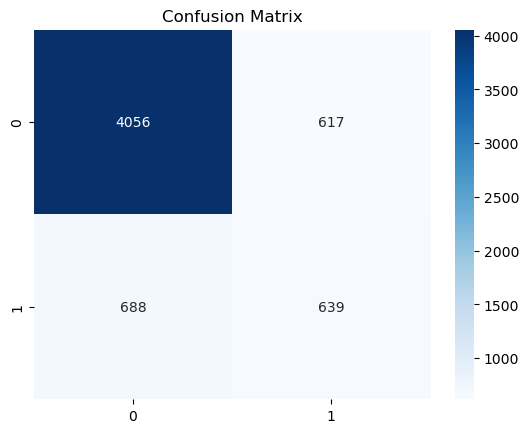

In [62]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

SHAP Explainability

 97%|=================== | 194/200 [00:19<00:00]       

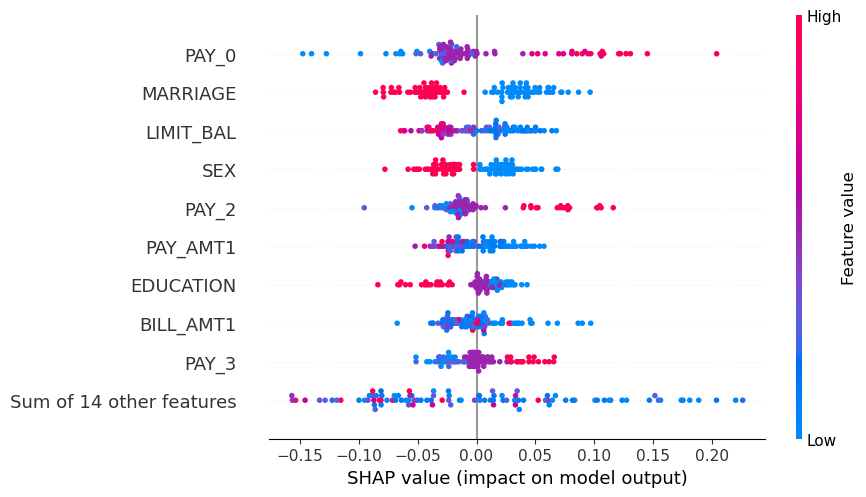

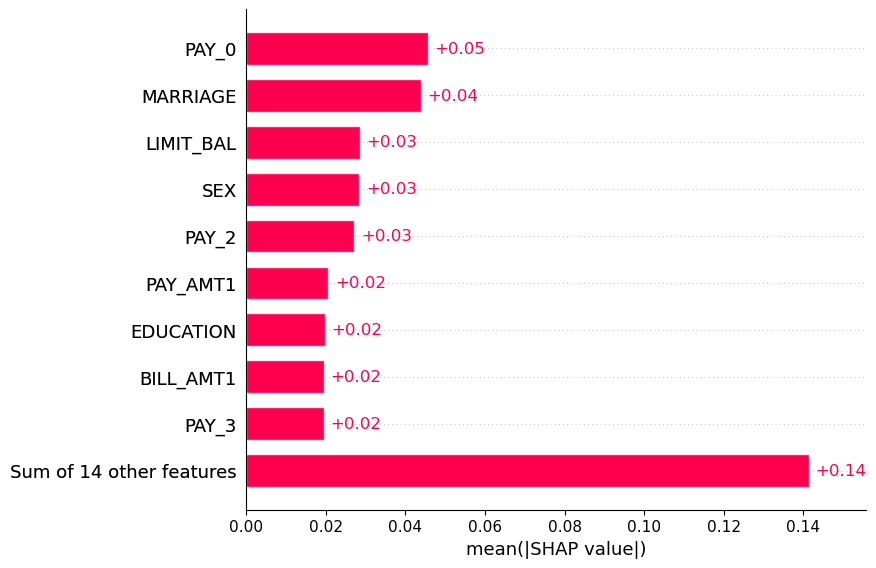

In [63]:
import shap

X_sample = pd.DataFrame(X_test[:100], columns=X.columns)

explainer = shap.Explainer(best_model, X_sample)

shap_values = explainer(
    X_sample,
    check_additivity=False
)

# SHAP summary plot
shap.plots.beeswarm(shap_values[:, :, 1])

# SHAP feature importance plot
shap.plots.bar(shap_values[:, :, 1])

Risk Grouping

In [64]:
def risk_group(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

Predict With Risk Group

In [65]:
for i in range(30):
    
    prob = best_model.predict_proba(X_test)[i][1]
    prediction = best_model.predict(X_test)[i]

    pred_label = "Default" if prediction == 1 else "Not Default"
    group = risk_group(prob)

    print(i, pred_label, prob, group)

0 Not Default 0.42 Medium Risk
1 Not Default 0.4 Medium Risk
2 Not Default 0.32 Medium Risk
3 Not Default 0.1 Low Risk
4 Not Default 0.07 Low Risk
5 Default 0.56 Medium Risk
6 Not Default 0.29 Low Risk
7 Not Default 0.01 Low Risk
8 Not Default 0.23 Low Risk
9 Not Default 0.13 Low Risk
10 Not Default 0.33 Medium Risk
11 Not Default 0.365 Medium Risk
12 Not Default 0.29 Low Risk
13 Not Default 0.22 Low Risk
14 Not Default 0.11 Low Risk
15 Default 0.68 Medium Risk
16 Not Default 0.17 Low Risk
17 Not Default 0.44 Medium Risk
18 Not Default 0.06 Low Risk
19 Not Default 0.17 Low Risk
20 Not Default 0.06 Low Risk
21 Not Default 0.23 Low Risk
22 Not Default 0.3 Medium Risk
23 Default 0.51 Medium Risk
24 Not Default 0.3 Medium Risk
25 Default 0.66 Medium Risk
26 Not Default 0.25 Low Risk
27 Not Default 0.09 Low Risk
28 Default 0.84 High Risk
29 Default 0.55 Medium Risk


In [66]:
import joblib

# Save the best model
joblib.dump(best_model, 'best_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save feature names for the web app
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

print("Model, scaler, and feature names saved successfully!")

Model, scaler, and feature names saved successfully!
